# Wasserstein Generative Adversarial Networks (WGAN)

Neste notebook, vamos explorar a Wasserstein GAN (WGAN), uma evolução significativa das Redes Adversariais Generativas que visa resolver alguns dos problemas mais persistentes do treinamento de GANs tradicionais, como a instabilidade e o colapso de modo. A principal inovação da WGAN é a substituição da divergência Jensen-Shannon (JS), implícita na função de custo da GAN original, pela Distância de Wasserstein-1, também conhecida como "Earth Mover's Distance". Isso resulta em uma função de perda que se correlaciona melhor com a qualidade das imagens geradas e proporciona gradientes mais estáveis, tornando o treinamento mais robusto. Construiremos nossa WGAN sobre a arquitetura convolucional da DCGAN, modificando a função de perda, a arquitetura do "Crítico" e o algoritmo de treinamento.

### A Distância de Wasserstein

O treinamento de GANs tradicionais é notoriamente instável. Isso se deve em grande parte à função de perda baseada na divergência JS, que pode saturar facilmente, resultando em gradientes que desaparecem (*vanishing gradients*). Quando o Discriminador se torna muito bom, o gradiente para o Gerador vai a zero, e o aprendizado para.

A WGAN propõe o uso da Distância de Wasserstein-1 ($W(P_r, P_g)$), que mede a "distância" entre a distribuição de dados reais ($P_r$) e a distribuição de dados gerados ($P_g$). Intuitivamente, pode ser vista como o "custo" mínimo para transformar uma distribuição na outra, como o custo de mover uma pilha de terra para que ela assuma a forma de outra.

$$
W(P_r, P_g) = \inf_{\gamma \in \Pi(P_r, P_g)} \mathbb{E}_{(x, y) \sim \gamma} [\|x - y\|]
$$

Esta formulação é intratável. No entanto, a dualidade de Kantorovich-Rubinstein nos oferece uma forma alternativa e mais prática:

$$
W(P_r, P_g) = \sup_{\|f\|_L \le 1} \mathbb{E}_{x \sim P_r}[f(x)] - \mathbb{E}_{x \sim P_g}[f(x)]
$$

Aqui, o supremo é obtido sobre todas as funções 1-Lipschitz $f$. Uma função é K-Lipschitz se $|f(x_1) - f(x_2)| \le K|x_1 - x_2|$. Na prática, a WGAN parametriza a função $f$ com uma rede neural, que chamamos de **Crítico** (em vez de Discriminador). O trabalho do Crítico é encontrar uma função $f$ que maximize a diferença acima. O trabalho do Gerador é produzir amostras que minimizem essa mesma diferença.

Para forçar a restrição de Lipschitz, o artigo original da WGAN propõe uma solução simples: o **weight clipping**. Após cada atualização de gradiente, os pesos do Crítico são "clipados" para um pequeno intervalo, como $[-0.01, 0.01]$.

In [1]:
import torch
from torch import nn
from torch.optim import Adam, RMSprop
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Preparação dos Dados (MNIST)

Para treinar nossa DCGAN, utilizaremos o dataset MNIST. As imagens serão redimensionadas para 32x32 para facilitar uma arquitetura com múltiplas camadas de convolução transposta que dobram a dimensão espacial. Além disso, normalizaremos os pixels das imagens para o intervalo `[-1, 1]`, que corresponde à faixa da função de ativação `Tanh` na camada de saída do nosso Gerador.

In [3]:
batch_size = 128
image_size = 32

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]) # Normaliza para [-1, 1]
])

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Número de batches de treino: {len(train_loader)}")
print(f"Número de batches de teste: {len(test_loader)}")

Número de batches de treino: 469
Número de batches de teste: 79


### O Gerador

A arquitetura do Gerador pode ser mantida exatamente a mesma da DCGAN. Sua função ainda é mapear um vetor do espaço latente para o espaço de imagens. A inovação da WGAN não está na arquitetura dos modelos, mas sim na forma como eles são treinados.

In [ ]:
# class Generator(nn.Module):
#     def __init__(self, latent_dim, img_channels, features_g):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.ConvTranspose2d(latent_dim, features_g * 8, kernel_size=4, stride=1, padding=0, bias=False),
#             nn.BatchNorm2d(features_g * 8),
#             nn.ReLU(True),

#             nn.ConvTranspose2d(features_g * 8, features_g * 4, kernel_size=4, stride=2, padding=1, bias=False),
#             nn.BatchNorm2d(features_g * 4),
#             nn.ReLU(True),

#             nn.ConvTranspose2d(features_g * 4, features_g * 2, kernel_size=4, stride=2, padding=1, bias=False),
#             nn.BatchNorm2d(features_g * 2),
#             nn.ReLU(True),
            
#             nn.ConvTranspose2d(features_g * 2, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
#             nn.Tanh()
#         )

#     def forward(self, input):
#         return self.net(input)

In [27]:
class Generator(nn.Module):
    def __init__(self, latent_dim, img_channels, features_g):
        super().__init__()
        self.net = nn.Sequential(
            # Entrada: [100, 1, 1]
            nn.ConvTranspose2d(latent_dim, features_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(features_g * 2, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.net(input)

### O Crítico (Critic)

A arquitetura do Discriminador da DCGAN é reaproveitada, mas com uma mudança: a camada final de ativação `Sigmoid` é **removida**. O modelo, que agora chamamos de Crítico, não deve produzir uma probabilidade, mas sim um score (um número real) para cada imagem. Esse score é usado para aproximar a Distância de Wasserstein.

In [28]:
# class Critic(nn.Module):
#     def __init__(self, img_channels, features_d):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Conv2d(img_channels, features_d, 4, 2, 1, bias=False),
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(features_d, features_d * 2, 4, 2, 1, bias=False),
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1, bias=False),
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(features_d * 4, 1, 4, 1, 0, bias=False),
#         )

#     def forward(self, x):
#         return self.net(x)

In [29]:
class Critic(nn.Module):
    def __init__(self, img_channels, features_d):
        super().__init__()
        self.net = nn.Sequential(
            # Entrada: [1, 32, 32]
            nn.Conv2d(img_channels, features_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(features_d, features_d * 2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(features_d * 4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x)

### Inicialização e Instanciação dos Modelos

Instanciamos os modelos e aplicamos a mesma inicialização de pesos da DCGAN. A mudança principal aqui é o otimizador: o artigo da WGAN recomenda o uso do `RMSprop` em vez de Adam com momento, pois observaram maior estabilidade. Não precisamos mais de uma função de perda como `BCELoss`, pois o custo será calculado diretamente a partir dos scores do Crítico.

In [30]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [39]:
features_g = 64
features_d = 64
latent_dim = 128
img_channels = 1

# Instanciação dos modelos
generator = Generator(latent_dim, img_channels, features_g=features_g).to(device)
generator.apply(weights_init)

critic = Critic(img_channels, features_d=features_d).to(device)
critic.apply(weights_init)

print("Generator Architecture:\n", generator)
print("\nCritic Architecture:\n", critic)

Generator Architecture:
 Generator(
  (net): Sequential(
    (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

Critic Architecture:
 Critic(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
 

In [40]:
lr = 0.00005

# Otimizadores (RMSprop é recomendado para WGAN)
optimizer_g = RMSprop(generator.parameters(), lr=lr)
optimizer_c = RMSprop(critic.parameters(), lr=lr)

### Loop de Treinamento

O loop de treinamento da WGAN é diferente do de uma GAN padrão. Para cada atualização do Gerador, o Crítico é atualizado múltiplas vezes (`n_critic`). Isso é feito para garantir que o Crítico se aproxime bem da função 1-Lipschitz ótima.

1.  **Treinamento do Crítico**:
    * A perda do Crítico visa maximizar $f(x) - f(G(z))$. Como otimizadores fazem minimização, minimizamos o negativo: $-(f(x) - f(G(z)))$, que é $f(G(z)) - f(x)$.
    * Após a atualização dos pesos, aplicamos o **weight clipping** para forçar a restrição de Lipschitz.

2.  **Treinamento do Gerador**:
    * A perda do Gerador visa minimizar a Distância de Wasserstein, o que corresponde a maximizar o score que o Crítico dá para suas imagens falsas, $f(G(z))$. Portanto, minimizamos $-f(G(z))$.

In [41]:
def show_generated_images(generator, fixed_noise, epoch, nrow=8):
    generator.eval()

    with torch.no_grad():
        fake_imgs = generator(fixed_noise).detach().cpu()

    # volta de [-1, 1] para [0, 1]
    fake_imgs = (fake_imgs + 1) / 2

    grid = vutils.make_grid(
        fake_imgs,
        nrow=nrow,
        padding=2,
        normalize=False
    )

    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title(f"Época {epoch}")
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.show()

    generator.train()

Epoch [1/5]: 100%|██████████| 469/469 [00:55<00:00,  8.45it/s, Loss C=-0.4742, Loss G=0.5285, W-dist=0.4742] 

Epoch [1/5] Loss C: -0.7081 | Loss G: -1.0935 | W-distance: 0.7081


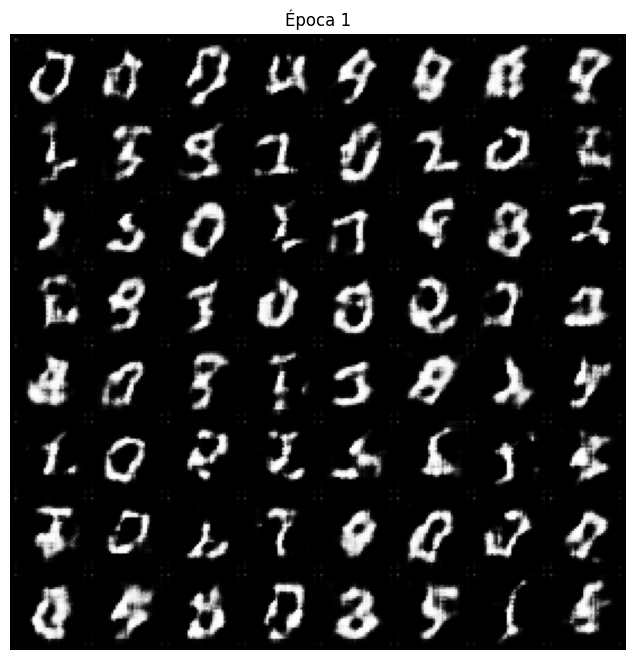

Epoch [2/5]: 100%|██████████| 469/469 [00:55<00:00,  8.45it/s, Loss C=-0.3558, Loss G=2.6174, W-dist=0.3558] 


Epoch [2/5] Loss C: -0.3884 | Loss G: -0.7488 | W-distance: 0.3884


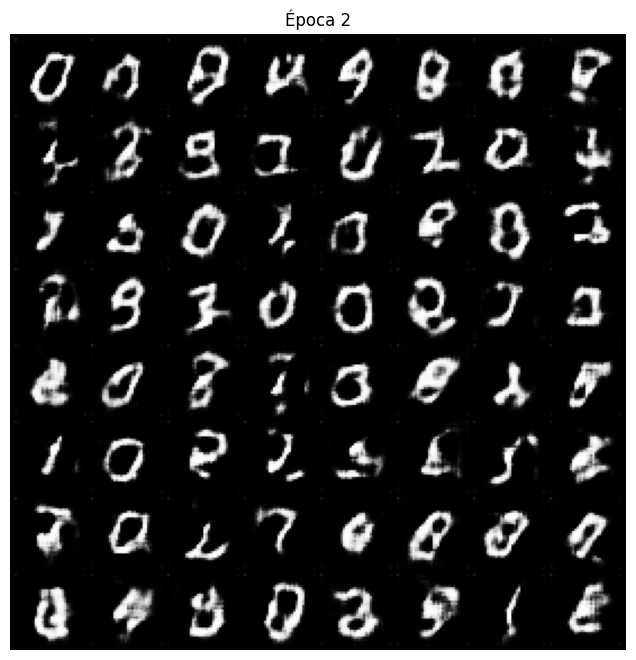

Epoch [3/5]: 100%|██████████| 469/469 [00:56<00:00,  8.26it/s, Loss C=-0.3011, Loss G=-0.1951, W-dist=0.3011] 

Epoch [3/5] Loss C: -0.3170 | Loss G: -1.6060 | W-distance: 0.3170


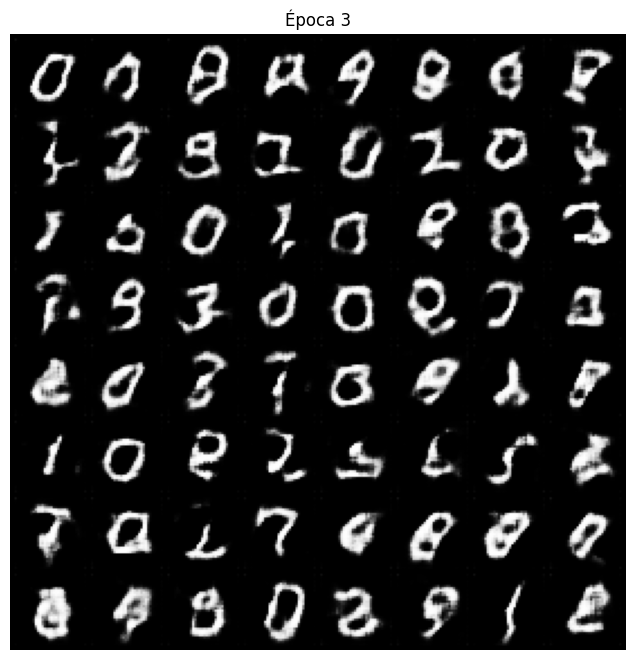

Epoch [4/5]: 100%|██████████| 469/469 [00:56<00:00,  8.24it/s, Loss C=-0.3654, Loss G=0.9073, W-dist=0.3654]  

Epoch [4/5] Loss C: -0.3134 | Loss G: -2.0246 | W-distance: 0.3134


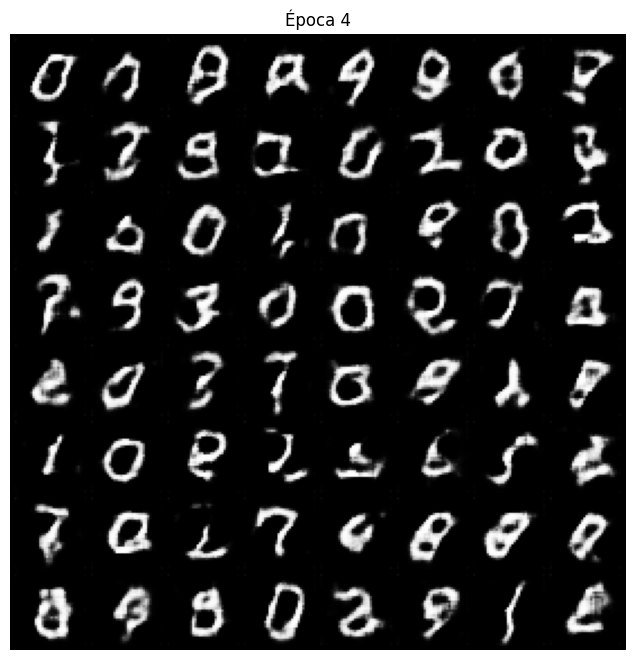

Epoch [5/5]: 100%|██████████| 469/469 [00:57<00:00,  8.10it/s, Loss C=-0.2178, Loss G=-4.2170, W-dist=0.2178] 


Epoch [5/5] Loss C: -0.2905 | Loss G: -2.3010 | W-distance: 0.2905


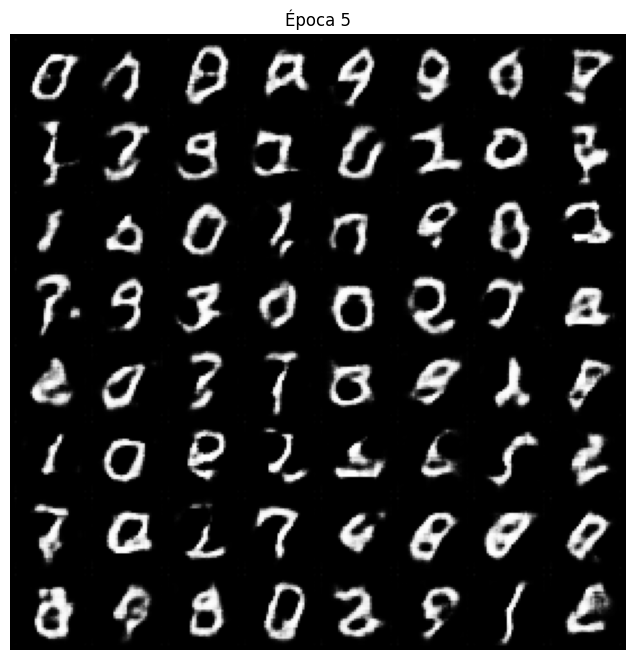

In [43]:
num_epochs = 5
n_critic = 10
clip_value = 0.01

g_losses = []
c_losses = []
wasserstein_estimates = []

fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

for epoch in range(num_epochs):
    generator.train()
    critic.train()

    running_loss_g = 0.0
    running_loss_c = 0.0
    running_w_distance = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

    for batch_idx, (real_imgs, _) in enumerate(progress_bar):
        real_imgs = real_imgs.to(device)
        current_batch_size = real_imgs.size(0)

        # ====================================================
        # 1. Treinar o crítico n_critic vezes
        # ====================================================

        for _ in range(n_critic):
            noise = torch.randn(current_batch_size, latent_dim, 1, 1, device=device)
            fake_imgs = generator(noise).detach()

            critic_real = critic(real_imgs).view(-1)
            critic_fake = critic(fake_imgs).view(-1)

            wasserstein_distance = critic_real.mean() - critic_fake.mean()

            # Queremos maximizar:
            # E[C(real)] - E[C(fake)]
            #
            # Como o otimizador minimiza, usamos:
            # loss_C = E[C(fake)] - E[C(real)]

            loss_c = critic_fake.mean() - critic_real.mean()

            optimizer_c.zero_grad()
            loss_c.backward()
            optimizer_c.step()

            # Weight clipping
            for p in critic.parameters():
                p.data.clamp_(-clip_value, clip_value)

        # ====================================================
        # 2. Treinar o gerador uma vez
        # ====================================================

        noise = torch.randn(current_batch_size, latent_dim, 1, 1, device=device)
        fake_imgs = generator(noise)

        # O gerador quer maximizar o score do crítico para imagens falsas.
        # Como minimizamos, usamos o negativo.

        loss_g = -critic(fake_imgs).view(-1).mean()

        optimizer_g.zero_grad()
        loss_g.backward()
        optimizer_g.step()

        # ====================================================
        # Logging
        # ====================================================

        running_loss_c += loss_c.item()
        running_loss_g += loss_g.item()
        running_w_distance += wasserstein_distance.item()

        progress_bar.set_postfix({
            "Loss C": f"{loss_c.item():.4f}",
            "Loss G": f"{loss_g.item():.4f}",
            "W-dist": f"{wasserstein_distance.item():.4f}"
        })

    epoch_loss_c = running_loss_c / len(train_loader)
    epoch_loss_g = running_loss_g / len(train_loader)
    epoch_w_distance = running_w_distance / len(train_loader)

    c_losses.append(epoch_loss_c)
    g_losses.append(epoch_loss_g)
    wasserstein_estimates.append(epoch_w_distance)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss C: {epoch_loss_c:.4f} | "
        f"Loss G: {epoch_loss_g:.4f} | "
        f"W-distance: {epoch_w_distance:.4f}"
    )

    show_generated_images(generator, fixed_noise, epoch + 1)

### Análise dos Resultados

Uma das vantagens da WGAN é que a perda do Crítico ($f(G(z)) - f(x)$) se aproxima da Distância de Wasserstein, que tende a se correlacionar com a qualidade das imagens geradas. Ao contrário da perda de uma GAN tradicional, aqui, uma perda do Crítico menor (mais negativa) indica que a distância entre as distribuições real e gerada é maior.

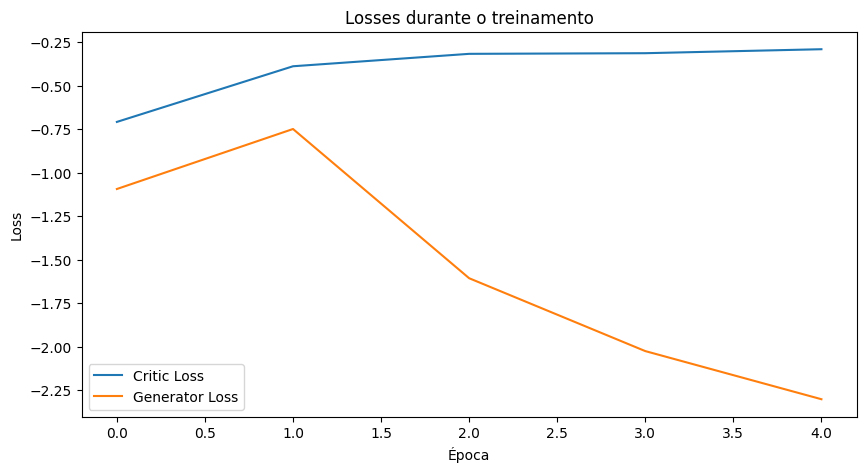

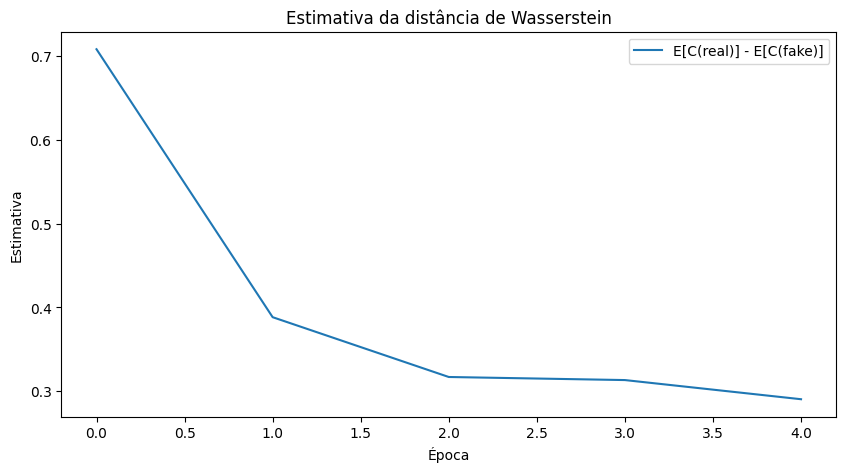

In [44]:
plt.figure(figsize=(10, 5))
plt.title("Losses durante o treinamento")
plt.plot(c_losses, label="Critic Loss")
plt.plot(g_losses, label="Generator Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.title("Estimativa da distância de Wasserstein")
plt.plot(wasserstein_estimates, label="E[C(real)] - E[C(fake)]")
plt.xlabel("Época")
plt.ylabel("Estimativa")
plt.legend()
plt.show()

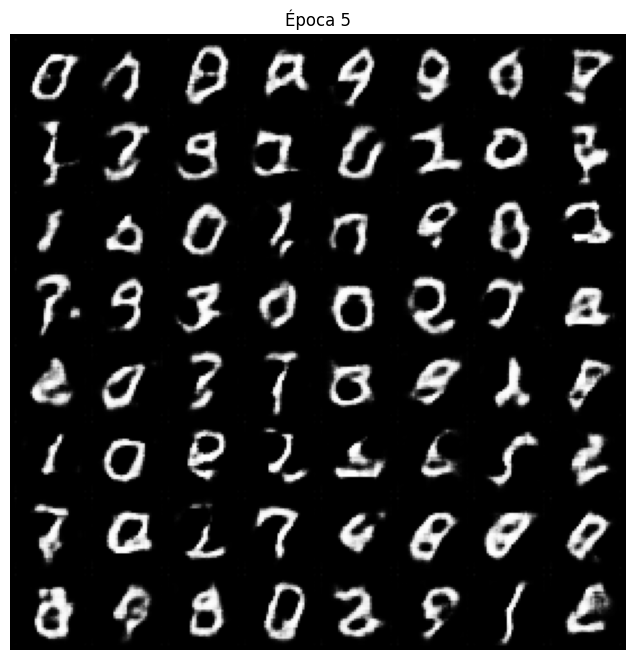

In [45]:
show_generated_images(generator, fixed_noise, num_epochs)